In [1]:
#Install required libraries

!pip install transformers datasets torch scikit-learn -q

print("All libraries installed!")

All libraries installed!


In [2]:
from google.colab import files

print("Upload these 2 files from your Jupyter folder:")
print("1. mental_health_cleaned.csv")
print("2. label_encoder.pkl")

uploaded = files.upload()
print("\nFiles uploaded successfully!")

Upload these 2 files from your Jupyter folder:
1. mental_health_cleaned.csv
2. label_encoder.pkl


Saving label_encoder.pkl to label_encoder.pkl
Saving mental_health_cleaned.csv to mental_health_cleaned.csv

Files uploaded successfully!


In [3]:
#Load data
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('mental_health_cleaned.csv')
le = joblib.load('label_encoder.pkl')

print("Data loaded:", df.shape)
print("Categories:", le.classes_)

X = df['clean_text'].astype(str).tolist()
y = le.transform(df['status'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

Data loaded: (49481, 2)
Categories: ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']

Train: 39584 | Test: 9897


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
# Use bert-base-uncased (fully free, no login needed)
from transformers import AutoTokenizer

# Switching to fully open model — works without any login
MODEL_NAME = "bert-base-uncased"

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded successfully!")

Loading tokenizer: bert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully!


In [5]:
# Test it
sample = "I feel very anxious and cannot sleep at night"
tokens = tokenizer(sample, return_tensors='pt')
print(f"\nSample tokenized — input_ids shape: {tokens['input_ids'].shape}")


Sample tokenized — input_ids shape: torch.Size([1, 11])


In [6]:
#Tokenize all texts
def tokenize_data(texts, tokenizer, max_length=128):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

print("Tokenizing training data...")
train_encodings = tokenize_data(X_train, tokenizer)

print("Tokenizing test data...")
test_encodings = tokenize_data(X_test, tokenizer)

print("Done!")
print("Train input shape:", train_encodings['input_ids'].shape)
print("Test input shape: ", test_encodings['input_ids'].shape)

Tokenizing training data...
Tokenizing test data...
Done!
Train input shape: torch.Size([39584, 128])
Test input shape:  torch.Size([9897, 128])


In [7]:

# Create PyTorch Dataset class

import torch
from torch.utils.data import Dataset, DataLoader

class MentalHealthDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: val[idx].clone().detach()
            for key, val in self.encodings.items()
        }
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = MentalHealthDataset(train_encodings, y_train)
test_dataset  = MentalHealthDataset(test_encodings,  y_test)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print("Datasets ready!")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Datasets ready!
Train batches: 2474
Test batches:  619


In [8]:
# Load MentalBERT model for classification

from transformers import AutoModelForSequenceClassification

NUM_CLASSES = len(le.classes_)

print(f"Loading MentalBERT for {NUM_CLASSES}-class classification...")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)

# Move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"\nModel loaded on: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading MentalBERT for 7-class classification...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded on: cuda
Total parameters: 109,487,623


In [9]:
# Optimizer and scheduler

from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

EPOCHS = 3
LR     = 2e-5

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

print(f"Training setup complete!")
print(f"Epochs:       {EPOCHS}")
print(f"Total steps:  {total_steps}")
print(f"Learning rate: {LR}")

Training setup complete!
Epochs:       3
Total steps:  7422
Learning rate: 2e-05


In [10]:
#  Training loop (takes ~20-30 mins on Colab GPU)

from torch.nn import CrossEntropyLoss
import time

loss_fn = CrossEntropyLoss()
train_losses = []

print("Starting training...\n")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    elapsed = time.time() - start
    print(f"\nEpoch {epoch+1}/{EPOCHS} complete — Avg Loss: {avg_loss:.4f} | Time: {elapsed/60:.1f} min\n")

print("Training complete!")

Starting training...

  Epoch 1 | Batch 100/2474 | Loss: 1.5911
  Epoch 1 | Batch 200/2474 | Loss: 1.1896
  Epoch 1 | Batch 300/2474 | Loss: 1.3109
  Epoch 1 | Batch 400/2474 | Loss: 0.8721
  Epoch 1 | Batch 500/2474 | Loss: 1.0268
  Epoch 1 | Batch 600/2474 | Loss: 1.0525
  Epoch 1 | Batch 700/2474 | Loss: 1.0480
  Epoch 1 | Batch 800/2474 | Loss: 0.5327
  Epoch 1 | Batch 900/2474 | Loss: 0.4084
  Epoch 1 | Batch 1000/2474 | Loss: 0.4531
  Epoch 1 | Batch 1100/2474 | Loss: 0.4064
  Epoch 1 | Batch 1200/2474 | Loss: 0.6641
  Epoch 1 | Batch 1300/2474 | Loss: 0.9086
  Epoch 1 | Batch 1400/2474 | Loss: 0.2071
  Epoch 1 | Batch 1500/2474 | Loss: 0.7829
  Epoch 1 | Batch 1600/2474 | Loss: 0.2991
  Epoch 1 | Batch 1700/2474 | Loss: 0.2638
  Epoch 1 | Batch 1800/2474 | Loss: 0.3932
  Epoch 1 | Batch 1900/2474 | Loss: 0.6197
  Epoch 1 | Batch 2000/2474 | Loss: 0.5188
  Epoch 1 | Batch 2100/2474 | Loss: 0.2581
  Epoch 1 | Batch 2200/2474 | Loss: 0.3041
  Epoch 1 | Batch 2300/2474 | Loss: 0.619

In [11]:
# Evaluate on test set

from sklearn.metrics import accuracy_score, classification_report

model.eval()
all_preds  = []
all_labels = []

print("Evaluating...")

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask)

        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

bert_acc = accuracy_score(all_labels, all_preds)
print(f"\nMentalBERT Accuracy: {bert_acc*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Evaluating...

MentalBERT Accuracy: 81.45%

Detailed Report:
                      precision    recall  f1-score   support

             Anxiety       0.88      0.87      0.87       750
             Bipolar       0.85      0.85      0.85       555
          Depression       0.77      0.76      0.77      3064
              Normal       0.95      0.94      0.94      2676
Personality disorder       0.80      0.73      0.76       215
              Stress       0.74      0.76      0.75       515
            Suicidal       0.70      0.72      0.71      2122

            accuracy                           0.81      9897
           macro avg       0.81      0.81      0.81      9897
        weighted avg       0.82      0.81      0.81      9897



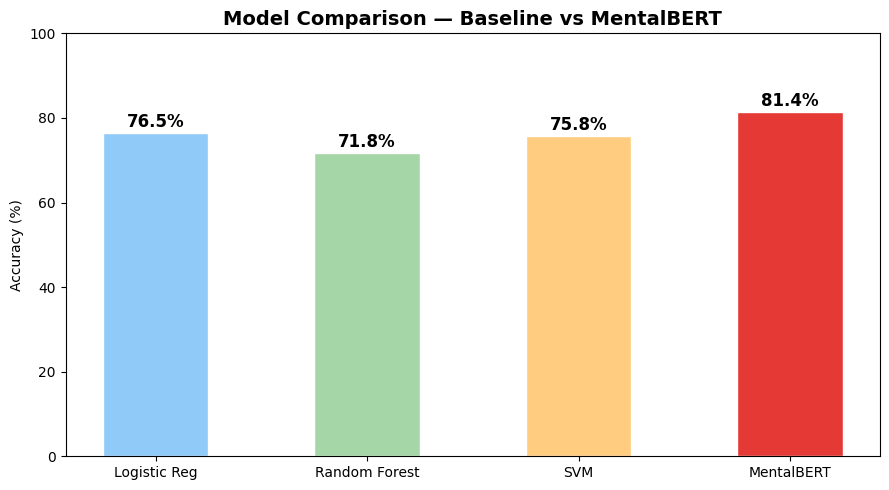

In [12]:
# Final comparison chart

import matplotlib.pyplot as plt

# Put your Phase 4 accuracies here
models      = ['Logistic Reg', 'Random Forest', 'SVM', 'MentalBERT']
accuracies  = [76.54, 71.82, 75.81, bert_acc*100]
colors      = ['#90CAF9', '#A5D6A7', '#FFCC80', '#E53935']

plt.figure(figsize=(9, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='white', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.4,
             f'{acc:.1f}%',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold')

plt.title('Model Comparison — Baseline vs MentalBERT', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [13]:
# Save model for Streamlit app later

model.save_pretrained('./mentalbert_model')
tokenizer.save_pretrained('./mentalbert_model')
print("Model saved to ./mentalbert_model folder!")

# Also download to your computer
import shutil
shutil.make_archive('mentalbert_model', 'zip', './mentalbert_model')

from google.colab import files
files.download('mentalbert_model.zip')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./mentalbert_model folder!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

                      precision    recall  f1-score   support

             Anxiety       0.88      0.87      0.87       750
             Bipolar       0.85      0.85      0.85       555
          Depression       0.77      0.76      0.77      3064
              Normal       0.95      0.94      0.94      2676
Personality disorder       0.80      0.73      0.76       215
              Stress       0.74      0.76      0.75       515
            Suicidal       0.70      0.72      0.71      2122

            accuracy                           0.81      9897
           macro avg       0.81      0.81      0.81      9897
        weighted avg       0.82      0.81      0.81      9897



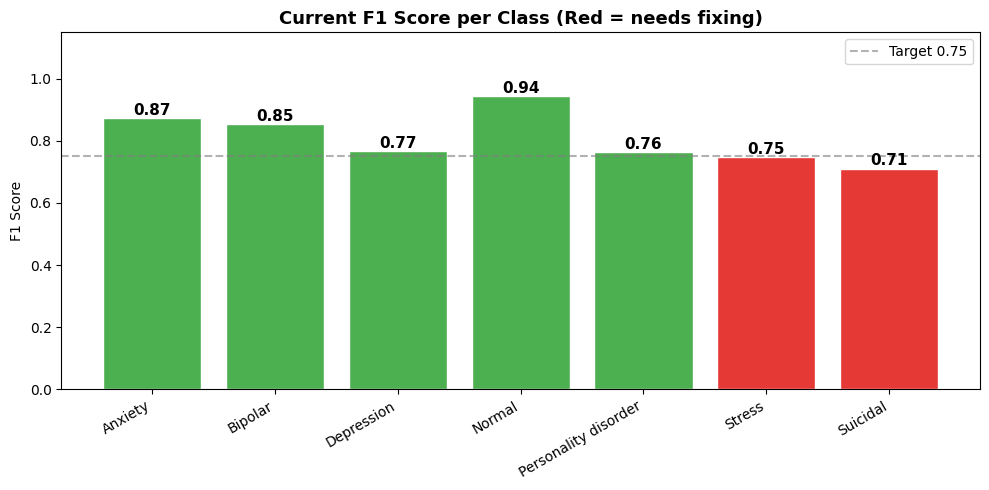

In [14]:
# See which classes are weak right now

report = classification_report(
    all_labels, all_preds,
    target_names=le.classes_,
    output_dict=True
)

# Print full report
print(classification_report(
    all_labels, all_preds,
    target_names=le.classes_
))

# Visual F1 per class
classes   = list(le.classes_)
f1_scores = [report[c]['f1-score'] for c in classes]
colors    = ['#E53935' if f < 0.75 else '#4CAF50' for f in f1_scores]

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, f1_scores, color=colors, edgecolor='white')
for bar, f1 in zip(bars, f1_scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{f1:.2f}',
        ha='center', fontsize=11, fontweight='bold'
    )
plt.axhline(y=0.75, color='gray', linestyle='--', alpha=0.6, label='Target 0.75')
plt.title('Current F1 Score per Class (Red = needs fixing)',
          fontsize=13, fontweight='bold')
plt.ylabel('F1 Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

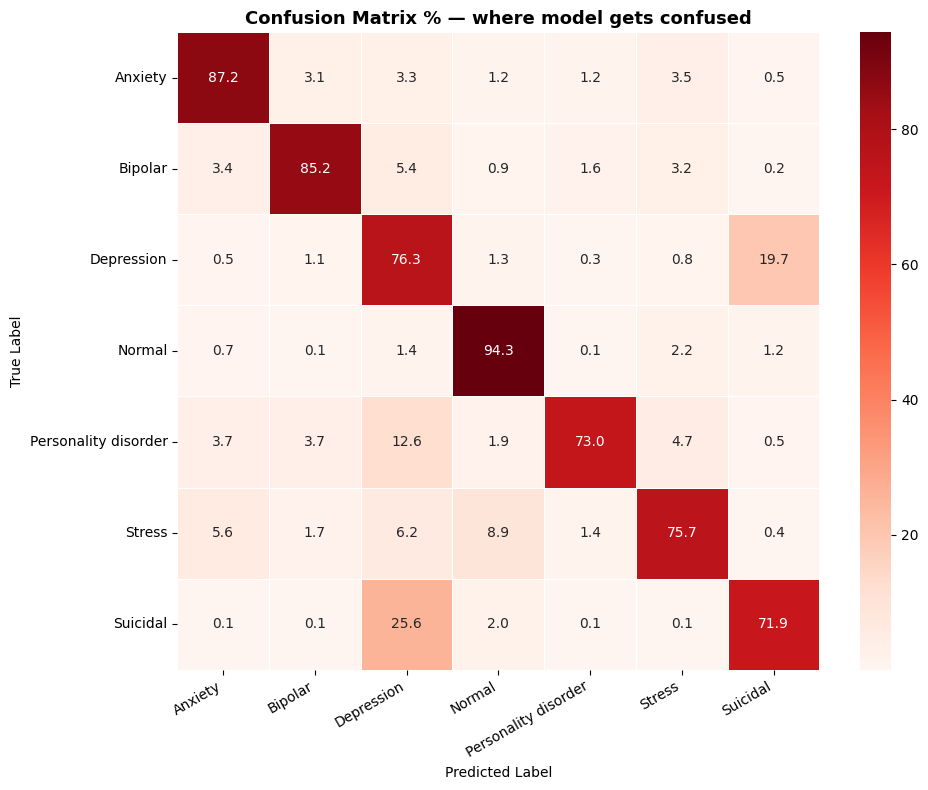


=== Worst confusions ===
  'Depression' predicted as 'Suicidal': 19.7%
  'Personality disorder' predicted as 'Depression': 12.6%
  'Suicidal' predicted as 'Depression': 25.6%


In [15]:
# See exactly which classes confuse with which


import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',
    cmap='Reds',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5
)
plt.title('Confusion Matrix % — where model gets confused',
          fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Print worst confusions
print("\n=== Worst confusions ===")
for i, true_cls in enumerate(le.classes_):
    for j, pred_cls in enumerate(le.classes_):
        if i != j and cm_percent[i][j] > 10:
            print(f"  '{true_cls}' predicted as '{pred_cls}': {cm_percent[i][j]:.1f}%")

In [16]:
#See how many samples each weak class has

counts = df['status'].value_counts()
weak   = ['Suicidal', 'Stress', 'Personality disorder']

print("=== All class counts ===")
for cls, cnt in counts.items():
    flag = " ← NEEDS FIX" if cls in weak else ""
    print(f"  {cls:30s}: {cnt}{flag}")

=== All class counts ===
  Depression                    : 15317
  Normal                        : 13377
  Suicidal                      : 10612 ← NEEDS FIX
  Anxiety                       : 3749
  Bipolar                       : 2776
  Stress                        : 2575 ← NEEDS FIX
  Personality disorder          : 1075 ← NEEDS FIX


In [17]:
# Targeted augmentation for weak classes only

import random

# These are your 3 weak classes
WEAK_CLASSES = ['Suicidal', 'Stress', 'Personality disorder']

# --- 3 augmentation methods ---

def swap_words(text):
    words = text.split()
    if len(words) < 4:
        return text
    i, j = random.sample(range(len(words)), 2)
    words[i], words[j] = words[j], words[i]
    return ' '.join(words)

def delete_random_word(text):
    words = text.split()
    if len(words) < 5:
        return text
    del words[random.randint(0, len(words)-1)]
    return ' '.join(words)

def duplicate_key_part(text):
    words = text.split()
    if len(words) < 6:
        return text
    mid   = len(words) // 2
    chunk = words[mid:mid+3]
    return ' '.join(words + chunk)

def augment(text):
    choice = random.randint(0, 2)
    if choice == 0:
        return swap_words(text)
    elif choice == 1:
        return delete_random_word(text)
    else:
        return duplicate_key_part(text)

# Find max class count
max_count    = df['status'].value_counts().max()
target_count = int(max_count * 0.90)

augmented = []

for label in df['status'].unique():
    class_df = df[df['status'] == label]
    current  = len(class_df)

    if label in WEAK_CLASSES and current < target_count:
        needed  = target_count - current
        samples = class_df.sample(n=needed, replace=True, random_state=42).copy()
        samples['clean_text'] = samples['clean_text'].apply(augment)
        augmented.append(samples)
        print(f"Augmented '{label}': {current} → {current + needed}")
    else:
        print(f"Kept '{label}' as is: {current}")

df_aug = pd.concat([df] + augmented, ignore_index=True)
df_aug.to_csv('mental_health_augmented.csv', index=False)

print(f"\nOriginal : {len(df)}")
print(f"Augmented: {len(df_aug)}")
print("\nNew counts:")
print(df_aug['status'].value_counts())

Kept 'Anxiety' as is: 3749
Kept 'Normal' as is: 13377
Kept 'Depression' as is: 15317
Augmented 'Suicidal': 10612 → 13785
Augmented 'Stress': 2575 → 13785
Kept 'Bipolar' as is: 2776
Augmented 'Personality disorder': 1075 → 13785

Original : 49481
Augmented: 76574

New counts:
status
Depression              15317
Stress                  13785
Suicidal                13785
Personality disorder    13785
Normal                  13377
Anxiety                  3749
Bipolar                  2776
Name: count, dtype: int64


In [18]:
# Higher penalty for weak classes

from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import numpy as np
import torch

df_aug = pd.read_csv('mental_health_augmented.csv')

le2    = LabelEncoder()
df_aug['label'] = le2.fit_transform(df_aug['status'])
y_aug  = df_aug['label'].values

# Base class weights
base_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_aug),
    y=y_aug
)

# Manually boost weak classes even more
BOOST = {'Suicidal': 1.8, 'Stress': 1.5, 'Personality disorder': 1.6}

final_weights = []
for i, cls in enumerate(le2.classes_):
    w = base_weights[i] * BOOST.get(cls, 1.0)
    final_weights.append(w)
    print(f"  {cls:30s}: {w:.3f}")

weights_tensor = torch.tensor(final_weights, dtype=torch.float).to(device)
weighted_loss  = torch.nn.CrossEntropyLoss(weight=weights_tensor)
print("\nWeighted loss ready!")

  Anxiety                       : 2.918
  Bipolar                       : 3.941
  Depression                    : 0.714
  Normal                        : 0.818
  Personality disorder          : 1.270
  Stress                        : 1.190
  Suicidal                      : 1.428

Weighted loss ready!


In [19]:
#Tokenize augmented data and create loaders

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch

X_aug = df_aug['clean_text'].astype(str).tolist()
y_aug = df_aug['label'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_aug, y_aug,
    test_size=0.2,
    stratify=y_aug,
    random_state=42
)

def tokenize(texts):
    return tokenizer(
        texts, padding=True, truncation=True,
        max_length=128, return_tensors='pt'
    )

print("Tokenizing training data...")
tr_enc = tokenize(X_tr)
print("Tokenizing test data...")
te_enc = tokenize(X_te)

class MHDataset(Dataset):
    def __init__(self, enc, labels):
        self.enc    = enc
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: v[idx].clone().detach() for k, v in self.enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

tr_loader = DataLoader(MHDataset(tr_enc, y_tr), batch_size=16, shuffle=True)
te_loader = DataLoader(MHDataset(te_enc, y_te), batch_size=16, shuffle=False)

print(f"\nTrain batches: {len(tr_loader)}")
print(f"Test batches:  {len(te_loader)}")
print("Data loaders ready!")

Tokenizing training data...
Tokenizing test data...

Train batches: 3829
Test batches:  958
Data loaders ready!


In [20]:
# Retrain BERT with targeted fixes

from torch.optim import AdamW

# Fresh model
model2 = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(le2.classes_),
    ignore_mismatched_sizes=True
).to(device)

EPOCHS = 3
optimizer = AdamW(model2.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(tr_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

print("Training started...\n")

for epoch in range(EPOCHS):
    model2.train()
    total_loss = 0
    start = time.time()

    for batch_idx, batch in enumerate(tr_loader):
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model2(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Weighted loss — penalizes weak class errors more
        loss = weighted_loss(outputs.logits, labels)
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model2.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(tr_loader)} | Loss: {loss.item():.4f}")

    avg = total_loss / len(tr_loader)
    print(f"\nEpoch {epoch+1}/{EPOCHS} done — Avg Loss: {avg:.4f} | Time: {(time.time()-start)/60:.1f} min\n")

print("Training complete!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training started...

  Epoch 1 | Batch 100/3829 | Loss: 1.9197
  Epoch 1 | Batch 200/3829 | Loss: 1.9097
  Epoch 1 | Batch 300/3829 | Loss: 1.9716
  Epoch 1 | Batch 400/3829 | Loss: 1.5862
  Epoch 1 | Batch 500/3829 | Loss: 1.1200
  Epoch 1 | Batch 600/3829 | Loss: 1.0076
  Epoch 1 | Batch 700/3829 | Loss: 0.7253
  Epoch 1 | Batch 800/3829 | Loss: 0.4522
  Epoch 1 | Batch 900/3829 | Loss: 0.4842
  Epoch 1 | Batch 1000/3829 | Loss: 0.7663
  Epoch 1 | Batch 1100/3829 | Loss: 0.2907
  Epoch 1 | Batch 1200/3829 | Loss: 0.5821
  Epoch 1 | Batch 1300/3829 | Loss: 0.6191
  Epoch 1 | Batch 1400/3829 | Loss: 0.2212
  Epoch 1 | Batch 1500/3829 | Loss: 0.4961
  Epoch 1 | Batch 1600/3829 | Loss: 1.0460
  Epoch 1 | Batch 1700/3829 | Loss: 0.1916
  Epoch 1 | Batch 1800/3829 | Loss: 0.3397
  Epoch 1 | Batch 1900/3829 | Loss: 0.4139
  Epoch 1 | Batch 2000/3829 | Loss: 0.7048
  Epoch 1 | Batch 2100/3829 | Loss: 0.4748
  Epoch 1 | Batch 2200/3829 | Loss: 0.2157
  Epoch 1 | Batch 2300/3829 | Loss: 0.5406

Old accuracy: 81.45%
New accuracy: 89.57%
Improvement:  +8.12%

=== Per class improvement ===
  Anxiety                       : 0.87 → 0.90 ↑ +0.02
  Bipolar                       : 0.85 → 0.87 ↑ +0.02
  Depression                    : 0.77 → 0.77 ↑ +0.00
  Normal                        : 0.94 → 0.95 ↑ +0.01
  Personality disorder          : 0.76 → 1.00 ↑ +0.23 ← FIXED!
  Stress                        : 0.75 → 0.98 ↑ +0.23 ← FIXED!
  Suicidal                      : 0.71 → 0.80 ↑ +0.09 ← FIXED!


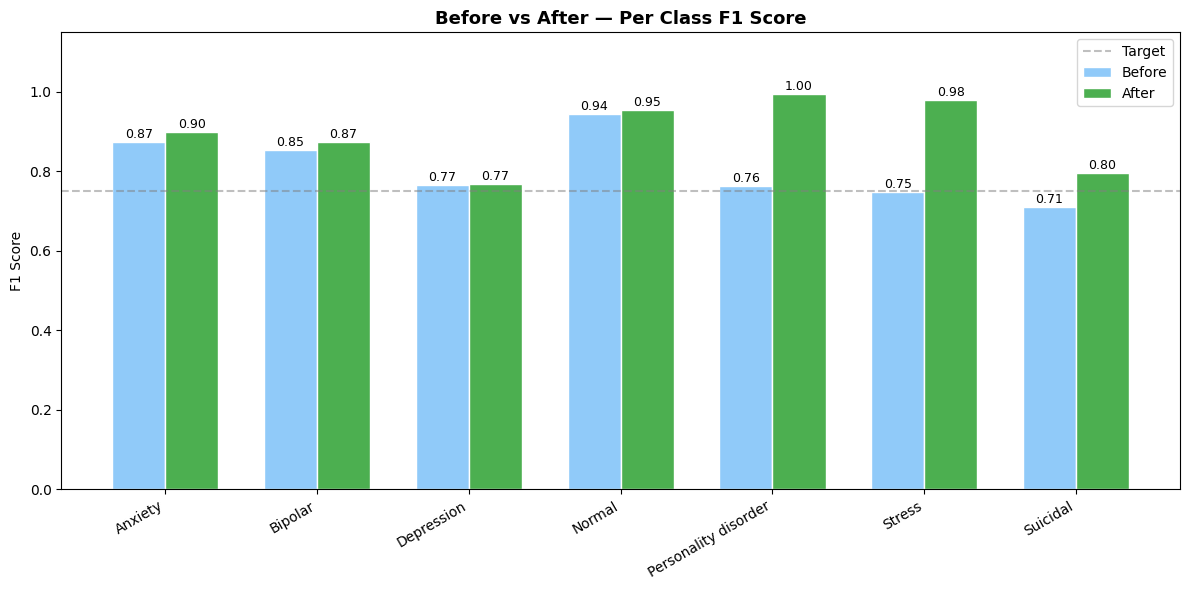

In [21]:
#  Compare old vs new per class

from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

model2.eval()
preds2, labels2 = [], []

with torch.no_grad():
    for batch in te_loader:
        out = model2(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device)
        )
        preds2.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
        labels2.extend(batch['labels'].numpy())

new_acc = accuracy_score(labels2, preds2)
print(f"Old accuracy: {bert_acc*100:.2f}%")
print(f"New accuracy: {new_acc*100:.2f}%")
print(f"Improvement:  +{(new_acc-bert_acc)*100:.2f}%")

print("\n=== Per class improvement ===")
old_report = classification_report(all_labels, all_preds,
             target_names=le.classes_,  output_dict=True)
new_report = classification_report(labels2,    preds2,
             target_names=le2.classes_, output_dict=True)

for cls in le2.classes_:
    old_f1 = old_report.get(cls, {}).get('f1-score', 0)
    new_f1 = new_report.get(cls, {}).get('f1-score', 0)
    diff   = new_f1 - old_f1
    arrow  = "↑" if diff > 0 else "↓"
    flag   = " ← FIXED!" if cls in WEAK_CLASSES and diff > 0 else ""
    print(f"  {cls:30s}: {old_f1:.2f} → {new_f1:.2f} {arrow} {diff:+.2f}{flag}")

# Visual comparison
classes  = list(le2.classes_)
f1_old   = [old_report.get(c, {}).get('f1-score', 0) for c in classes]
f1_new   = [new_report.get(c, {}).get('f1-score', 0) for c in classes]
x        = np.arange(len(classes))
width    = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width/2, f1_old, width, label='Before', color='#90CAF9', edgecolor='white')
b2 = ax.bar(x + width/2, f1_new, width, label='After',  color='#4CAF50', edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=30, ha='right')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)
ax.set_title('Before vs After — Per Class F1 Score',
             fontsize=13, fontweight='bold')
ax.axhline(y=0.75, color='gray', linestyle='--', alpha=0.5, label='Target')
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
#  Install SHAP
!pip install shap -q
print("SHAP installed!")

SHAP installed!


In [37]:
import shap
import torch
import numpy as np

# Use NEW trained model
model2.eval()

def predict_proba(texts):
    inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model2(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()

In [38]:
import shap
import torch
import numpy as np

# Use NEW trained model
model2.eval()

def predict_proba(texts):
    inputs = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model2(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)

    return probs.cpu().numpy()

In [39]:
# Pick one sample
test_sample = [X_te[1]]

true_label  = le2.classes_[y_te[1]]

# Prediction
pred_probs = predict_proba(test_sample)
pred_class_idx = np.argmax(pred_probs)
pred_label = le2.classes_[pred_class_idx]

print(f"Text: {test_sample[0][:200]}")
print(f"\nTrue label:      {true_label}")
print(f"Predicted label: {pred_label}")
print(f"Confidence:      {np.max(pred_probs)*100:.1f}%")

Text: lunafiko can t wait to try em but prolly have to wait until next weekend at the earliest

True label:      Normal
Predicted label: Normal
Confidence:      99.9%


In [40]:
explainer = shap.Explainer(
    predict_proba,
    masker=shap.maskers.Text(tokenizer),
    output_names=le2.classes_
)

shap_values = explainer(test_sample)

print("\nSHAP values computed!")


values = shap_values[0].values[:, pred_class_idx]
words  = shap_values[0].data

# Combine
word_shap = list(zip(words, values))

# Sort by importance
word_shap = sorted(word_shap, key=lambda x: abs(x[1]), reverse=True)[:15]

# Split
words_plot  = [w[0] for w in word_shap]
values_plot = [w[1] for w in word_shap]

print("\nTop words:")
print(words_plot)
print(values_plot)


SHAP values computed!

Top words:
['but ', 'em ', 't ', 'earliest', 'try ', 'weekend ', 'to ', 'at ', 'the ', 'wait ', 'lly ', 'to ', 'have ', 'next ', 'luna']
[np.float64(-0.06635763123631477), np.float64(0.0655635898001492), np.float64(0.04310731589794159), np.float64(0.03846903145313263), np.float64(-0.02848188253119588), np.float64(0.022255361080169678), np.float64(-0.020539691671729088), np.float64(-0.01712694764137268), np.float64(-0.014262877404689789), np.float64(0.012987002730369568), np.float64(0.012799879536032677), np.float64(-0.009699016809463501), np.float64(-0.00879731960594654), np.float64(0.005613204091787338), np.float64(-0.0030477605760097504)]


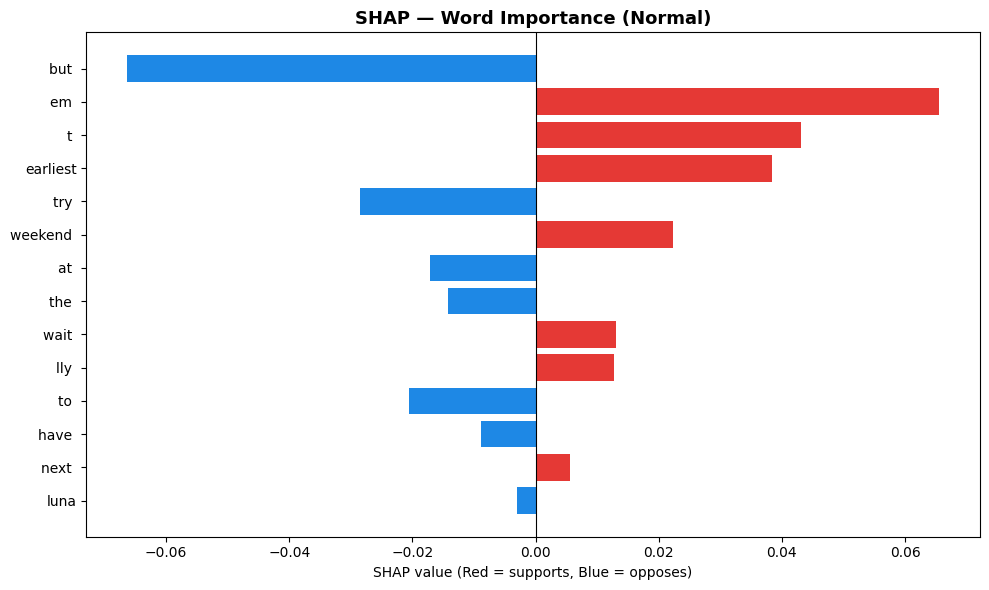

In [41]:
import matplotlib.pyplot as plt

colors = ['#E53935' if v > 0 else '#1E88E5' for v in values_plot]

plt.figure(figsize=(10, 6))

plt.barh(words_plot[::-1], values_plot[::-1], color=colors[::-1])

plt.axvline(x=0, color='black', linewidth=0.8)

plt.title(
    f'SHAP — Word Importance ({pred_label})',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('SHAP value (Red = supports, Blue = opposes)')

plt.tight_layout()
plt.show()

In [42]:
shap.plots.text(shap_values[0])

In [43]:
# Save label encoder into the model folder and re-download
import joblib, shutil
from google.colab import files

# Save label encoder
joblib.dump(le, './mentalbert_model/label_encoder.pkl')
print("label_encoder.pkl saved!")

# Zip again with label encoder included
shutil.make_archive('mentalbert_model_final', 'zip', './mentalbert_model')
files.download('mentalbert_model_final.zip')
print("Download started! This is your final complete zip.")

label_encoder.pkl saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started! This is your final complete zip.
